# Medical Insurance Cost Prediction

## Exploratory Data Analysis (EDA)

We are building a machine learning model that predicts a customer's future medical insurance charges based on demographic and health-related features. This helps insurance companies estimate premiums, improve pricing strategies, and provide instant quotes to customers.

In [21]:
# Data Manipulation
import pandas as pd
import matplotlib.pyplot as plt
# Data Visualization
import seaborn as sns
import numpy as np

### Why are we performing EDA?

EDA helps us understand the dataset by examining its structure, data types, missing values, duplicates, distributions, and relationships between variables. These insights guide preprocessing and model selection.


In [44]:
df=pd.read_csv("../data/insurance.csv")

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Observation

- Dataset contains 1338 rows and 7 columns.
- There are no missing values.
- Three columns are categorical:
  - sex
  - smoker
  - region
- Remaining columns are numerical.

In [26]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


 The data is the charges by the insurance company charged based on various features 
 
 The dependent features are charges and the other features are the independent features 
 
 The numerical columns are bmi,age,charges,children
 
 The region section need the feature engineering one hot encoding beacuse it has 4 regions which may affect the model

 The charges column needs standar scaler 
 
 The somker column should be 1,0 by feature engineering mapping 

In [27]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

The data has no null value

In [31]:
df.duplicated().sum()

np.int64(1)

In [47]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [33]:
df.max()

age                  64
sex                male
bmi               53.13
children              5
smoker              yes
region        southwest
charges     63770.42801
dtype: object

In [34]:
df.min()

age                18
sex            female
bmi             15.96
children            0
smoker             no
region      northeast
charges     1121.8739
dtype: object

In [39]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Observation

- Age ranges from 18 to 64 years.
- BMI has a wide range, suggesting we should inspect it for outliers.
- Charges show a large spread, indicating that some customers incur much higher medical costs than others.

# Conclusion

- No missing values were found.
- One duplicate record was identified.
- Numerical features have different ranges.
- Categorical features require encoding.
- Data is ready for feature engineering.

# Visualization

Here we use matplotlib and seaborn as the Visualization library 
We are doing visualization for getting better knowledge of datasets in EDA if datasets are to large in number then it is not possible to see the outliers and making the relationship between independent features and dependent features.

## Univariate Analysis

### Distribution of Numerical Features

Histograms are used to understand the distribution of numerical variables. They help identify the spread of data, skewness, unusual peaks, and potential outliers. Understanding these distributions helps us decide whether preprocessing steps such as transformations may be needed before model training.

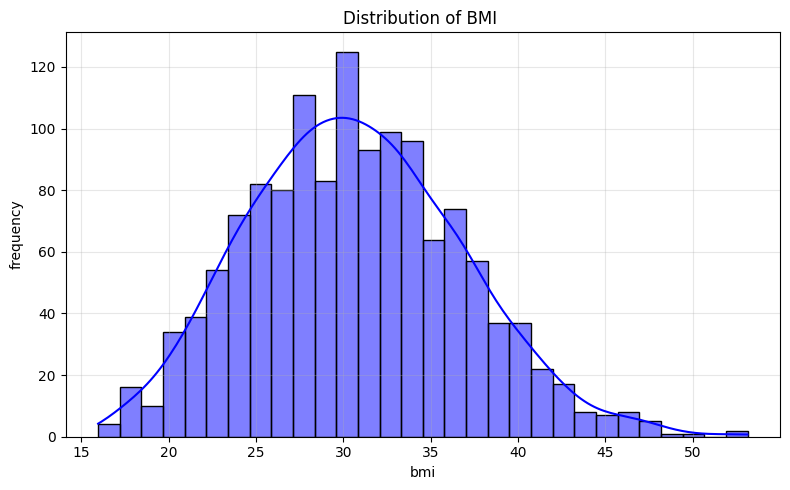

In [64]:
fig,ax=plt.subplots(figsize=(8,5))
sns.histplot(
    data=df,
    x="bmi",
   
    bins=30,
    kde=True,
    ax=ax,
    color="blue"
)
ax.set_title("Distribution of BMI ")
ax.set_xlabel("bmi")
ax.set_ylabel("frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

- Most BMI values lie within a moderate range 15-50.
- The distribution appears approximately more in the range of 25-35 and right skewed .
- Few bmi are very highly distributed which show that it is a outlier.
- We should further investigate whether extreme BMI values exist using a boxplot.

## Univariate Analysis of Categorical Features

### Distribution of Smoking Status

The `smoker` feature is one of the most important categorical variables in this dataset. Visualizing its distribution helps us understand the proportion of smokers and non-smokers, which may influence insurance charges and later model performance.

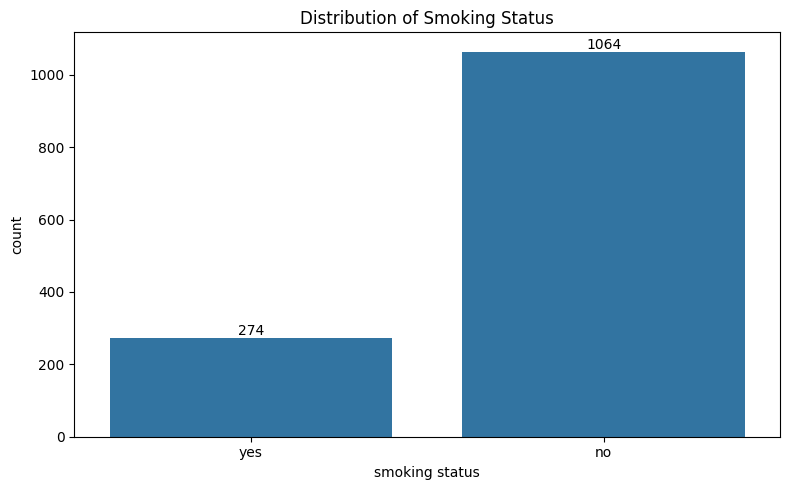

In [73]:
fig,ax=plt.subplots(figsize=(8,5))
sns.countplot(
    data=df,
    x="smoker",
)
ax.set_title("Distribution of Smoking Status")
ax.set_xlabel("smoking status")
ax.set_ylabel("count")
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container)
    

# Observation


- The dataset contains more non-smokers than smokers.
- This indicates that the dataset is slightly imbalanced with respect to smoking status.
- The countplot does not tell us whether smokers pay more. It only shows the number of individuals in each category.
- We need a bivariate analysis to study how smoking status affects insurance charges.

## Bivariate Analysis

### Smoking Status vs Insurance Charges

To understand how smoking status influences insurance charges, we compare the distribution of charges for smokers and non-smokers using a boxplot. This helps identify differences in median charges, spread, and potential outliers between the two groups.

C:\Users\adity\AppData\Local\Temp\ipykernel_14760\632036405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


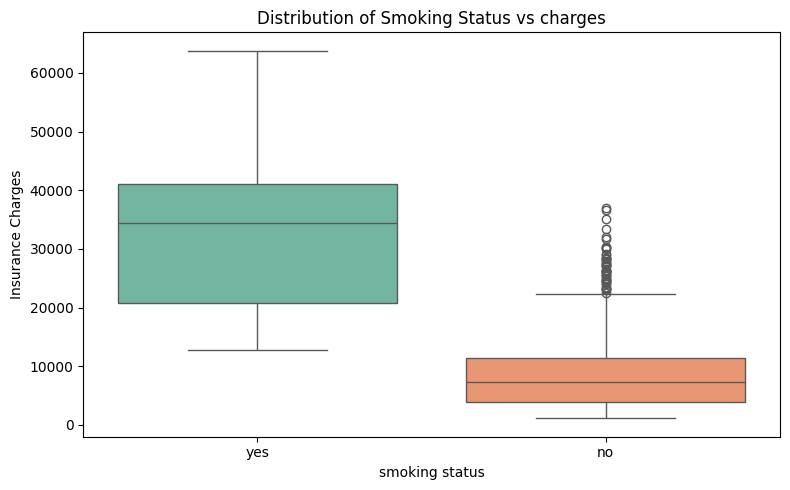

In [76]:
fig,ax=plt.subplots(figsize=(8,5))
sns.boxplot(
    data=df,
    x="smoker",
    y="charges",
    palette="Set2"
)
ax.set_title("Distribution of Smoking Status vs charges")
ax.set_xlabel("smoking status")
ax.set_ylabel("Insurance Charges")
plt.tight_layout()

### Observation

- Smokers have a much higher median insurance charge than non-smokers.
- The spread (IQR) of charges is much larger for smokers.
- Both groups contain outliers, but smokers generally incur substantially higher medical costs.
- Smoking status appears to be one of the strongest predictors of insurance charges and is likely to be an important feature for our regression model.
 

## Bivariate Analysis

### Age vs Insurance Charges

This scatter plot is used to examine the relationship between age and insurance charges. By coloring the points based on smoking status, we can also observe how smoking influences insurance costs across different age groups.

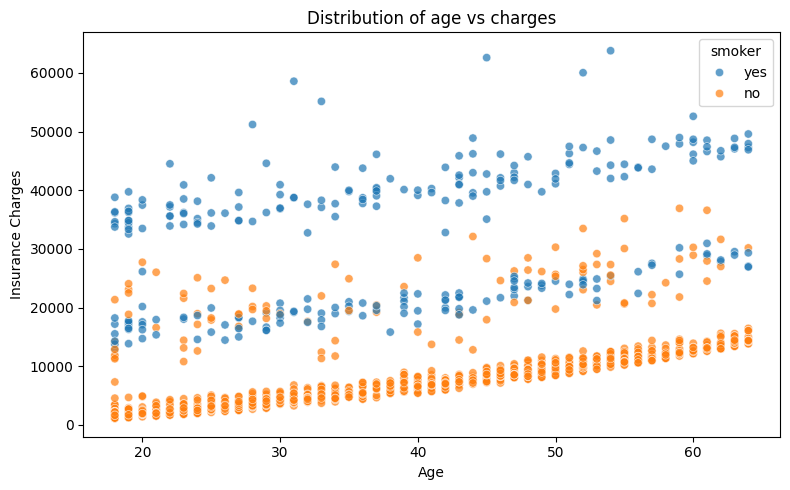

In [81]:
fig,ax=plt.subplots(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    alpha=0.7
)
ax.set_title("Distribution of age vs charges")
ax.set_xlabel("Age")
ax.set_ylabel("Insurance Charges")
plt.tight_layout()

### Observation

- Insurance charges generally increase with age.
- Smokers tend to incur significantly higher charges than non-smokers across almost all age groups.
- Older smokers appear to have the highest insurance costs.
- Smoking status amplifies the effect of age on insurance charges.

## Bivariate Analysis

### Bmi vs Insurance Charges

This scatter plot is used to examine the relationship between bi and insurance charges. By coloring the points based on smoking status, we can also observe how smoking influences insurance costs across different bmi groups.

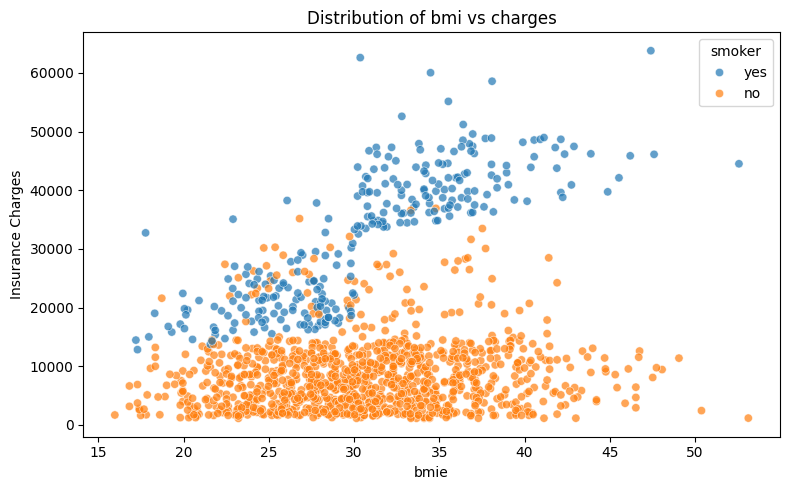

In [82]:
fig,ax=plt.subplots(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    alpha=0.7
)
ax.set_title("Distribution of bmi vs charges")
ax.set_xlabel("bmie")
ax.set_ylabel("Insurance Charges")
plt.tight_layout()

### Observation

- Insurance charges generally increase with bmi.
- Smokers tend to incur significantly higher charges than non-smokers across increasing bmi.
- Higher bmi smokers appear to have the highest insurance costs.
- Smoking status amplifies the effect of bmi on insurance charges.

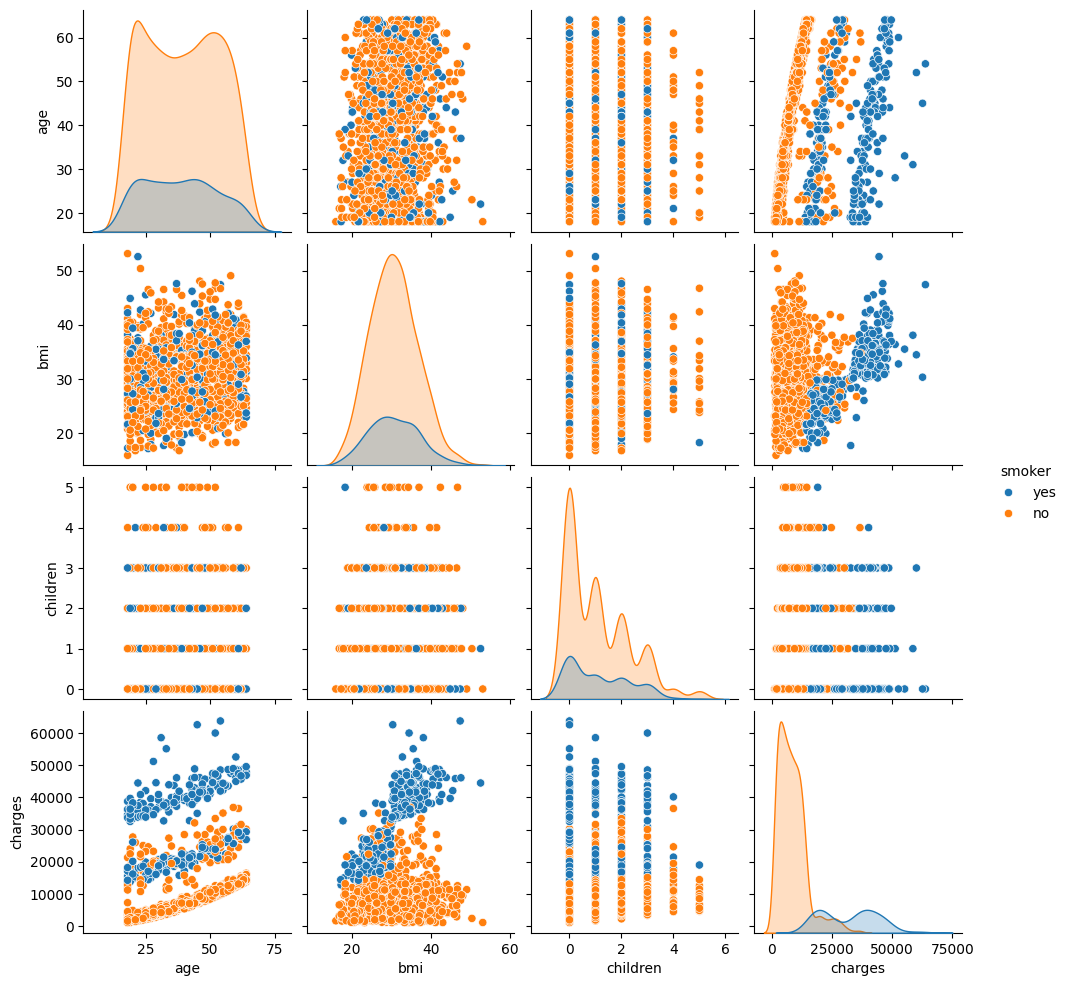

In [85]:
sns.pairplot(
    df,
    hue="smoker"
)

# Final Insights

1. The dataset contains no missing values.
2. One duplicate record was identified.
3. Smoking status is the strongest indicator of higher insurance charges.
4. Insurance charges generally increase with age.
5. BMI has a moderate positive relationship with insurance charges.
6. Numerical features will require scaling before model training.
7. Categorical variables require encoding.